In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_phone = pd.read_csv("../data/processed/phone_feature_extracted(4s).csv")
df_watch = pd.read_csv("../data/processed/watch_feature_extracted(4s).csv")

In [3]:
df_phone

,activity,x_accel_mean,x_accel_std,x_accel_p25,x_accel_p75,x_accel_kurt,x_accel_autocorr,x_accel_rms,x_accel_dom_freq,x_accel_spectral_energy,...,y_gyro_spectral_energy,z_gyro_mean,z_gyro_std,z_gyro_p25,z_gyro_p75,z_gyro_kurt,z_gyro_autocorr,z_gyro_rms,z_gyro_dom_freq,z_gyro_spectral_energy
0,A,0.796704,2.571532,-1.140656,2.981293,-0.912637,-0.046050,2.675243,3.835616,17378.371068,...,4557.733437,-0.159320,0.643462,-0.635208,0.305771,-0.895347,0.720786,0.658600,0.821918,1088.105736
1,A,0.623092,2.436439,-1.239281,2.044838,-0.264754,-0.098954,2.499867,3.797468,18289.537024,...,4626.186215,-0.039106,0.545919,-0.425026,0.368187,-0.520510,0.641162,0.543860,1.012658,918.222501
2,A,0.346919,2.815594,-1.381485,1.948769,1.474508,-0.350978,2.819144,3.797468,24424.837077,...,5169.533442,-0.105689,0.576126,-0.525681,0.331245,-0.796299,0.801552,0.582143,1.012658,1022.650703
3,A,0.449920,2.564634,-1.367882,2.639038,-0.348777,-0.055167,2.587964,3.750000,20916.365649,...,5130.490564,-0.123284,0.603884,-0.568279,0.377758,-0.929931,0.777079,0.612631,1.000000,1163.409312
4,A,0.772294,2.661322,-1.020157,2.374817,2.478645,-0.311006,2.754890,7.341772,21821.590546,...,4626.474757,-0.080078,0.616848,-0.442970,0.403763,-0.557358,0.770712,0.618141,1.012658,1172.326460
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41430,S,-1.686405,0.617093,-2.057921,-1.216071,-0.112409,0.793842,1.794703,0.200000,1890.852889,...,914.229009,-0.001587,0.244381,-0.137685,0.071639,0.670078,0.885071,0.243161,1.000000,295.659519
41431,S,-1.545417,0.626101,-2.058519,-0.995131,-1.026960,0.855599,1.666240,0.202020,1901.601650,...,741.513421,-0.020660,0.213598,-0.162453,0.100135,0.169924,0.917344,0.213518,0.808081,221.322812
41432,S,-0.782059,0.713963,-1.080154,-0.243094,1.009677,0.900248,1.056509,0.202020,2472.765966,...,579.441878,0.023274,0.230744,-0.141148,0.142745,2.020718,0.898557,0.230753,0.808081,258.281143
41433,S,-1.806619,0.559290,-2.024989,-1.586701,25.811835,-0.067786,1.890375,2.424242,1517.418014,...,886.925075,0.000721,0.203144,-0.083623,0.075634,6.418808,0.662241,0.202117,1.010101,200.188646


In [4]:
df_phone.skew(numeric_only=True)

x_accel_mean               -0.096341
x_accel_std                 2.749008
x_accel_p25                -0.018674
x_accel_p75                -0.093331
x_accel_kurt                5.685752
x_accel_autocorr           -0.651389
x_accel_rms                 0.473827
x_accel_dom_freq            1.501340
x_accel_spectral_energy     9.289536
y_accel_mean                0.437695
y_accel_std                 2.507976
y_accel_p25                 0.132539
y_accel_p75                 0.585533
y_accel_kurt                5.836604
y_accel_autocorr           -0.595748
y_accel_rms                -0.020457
y_accel_dom_freq            1.364447
y_accel_spectral_energy     7.480565
z_accel_mean                0.014422
z_accel_std                 2.150949
z_accel_p25                 0.253151
z_accel_p75                -0.228950
z_accel_kurt                5.951540
z_accel_autocorr           -0.436986
z_accel_rms                 0.373628
z_accel_dom_freq            1.617483
z_accel_spectral_energy     5.742633
x

In [5]:
X_phone = df_phone.drop(columns="activity")
y_phone = df_phone["activity"]

X_watch = df_watch.drop(columns="activity")
y_watch = df_watch["activity"]

In [6]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_phone = le.fit_transform(y_phone)
y_watch = le.fit_transform(y_watch)

In [7]:
from sklearn.model_selection import train_test_split

X_train_phone, X_test_phone, y_train_phone, y_test_phone = train_test_split(
    X_phone, y_phone, test_size=0.2, random_state=42
)

X_train_watch, X_test_watch, y_train_watch, y_test_watch = train_test_split(
    X_watch, y_watch, test_size=0.2, random_state=42
)

In [ ]:
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, f1_score


def objective(trial):

    n_estimators = trial.suggest_int("n_estimators", 100, 500)

    max_depth = trial.suggest_int("max_depth", 5, 50)

    min_samples_split = trial.suggest_int("min_samples_split", 2, 5)

    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 5)

    criterion = trial.suggest_categorical("criterion", ["entropy", "gini"])

    max_features = trial.suggest_categorical(
        "max_features", ["sqrt", "log2", 0.3, 0.5, 0.7]
    )

    max_samples = trial.suggest_categorical("max_samples", [0.9, 1])

    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        criterion=criterion,
        max_features=max_features,
        max_samples=max_samples,
        bootstrap=True,
        n_jobs=-1,
        random_state=42,
    )

    score = cross_val_score(
        model,
        X_train_phone,
        y_train_phone,
        cv=3,
        scoring=make_scorer(f1_score, average="macro"),
        n_jobs=-1,
    ).mean()

    return score


study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(),
)


study.optimize(objective, n_trials=50)

In [10]:
model = RandomForestClassifier(
    n_estimators=450,
    max_depth=30,
    min_samples_split=2,
    min_samples_leaf=1,
    criterion="entropy",
    n_jobs=-1,
)

score = cross_val_score(
    model,
    X_train_phone,
    y_train_phone,
    cv=3,
    scoring=make_scorer(f1_score, average="macro"),
    n_jobs=-1,
).mean()

score

np.float64(0.8491838733578786)

In [11]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import f1_score

dc = DummyClassifier(strategy="most_frequent", random_state=42)

dc.fit(X_train_phone, y_train_phone)

y_pred_dummy = dc.predict(X_test_phone)

# 4. Calculate the F1-score (weighted for multi-class)
f1_dummy = f1_score(y_test_phone, y_pred_dummy, average="weighted")

print(f"Dummy Classifier F1-score (weighted): {f1_dummy:.4f}")

Dummy Classifier F1-score (weighted): 0.0049


In [12]:
from sklearn.model_selection import cross_val_predict

y_preds_phone = cross_val_predict(
    model,
    X_train_phone,
    y_train_phone,
    cv=3,
    n_jobs=-1,
)

              precision    recall  f1-score   support

           0       0.95      0.95      0.95      1833
           1       0.96      0.97      0.97      1780
           2       0.86      0.92      0.89      1827
           3       0.87      0.84      0.85      1858
           4       0.82      0.87      0.85      1917
           5       0.92      0.88      0.90      1782
           6       0.87      0.85      0.86      1895
           7       0.84      0.81      0.83      1878
           8       0.82      0.76      0.79      1779
           9       0.84      0.79      0.81      1778
          10       0.84      0.80      0.82      1917
          11       0.84      0.79      0.81      1832
          12       0.75      0.84      0.79      1872
          13       0.76      0.77      0.76      1812
          14       0.82      0.79      0.81      1861
          15       0.91      0.90      0.91      1853
          16       0.89      0.88      0.88      1839
          17       0.72    

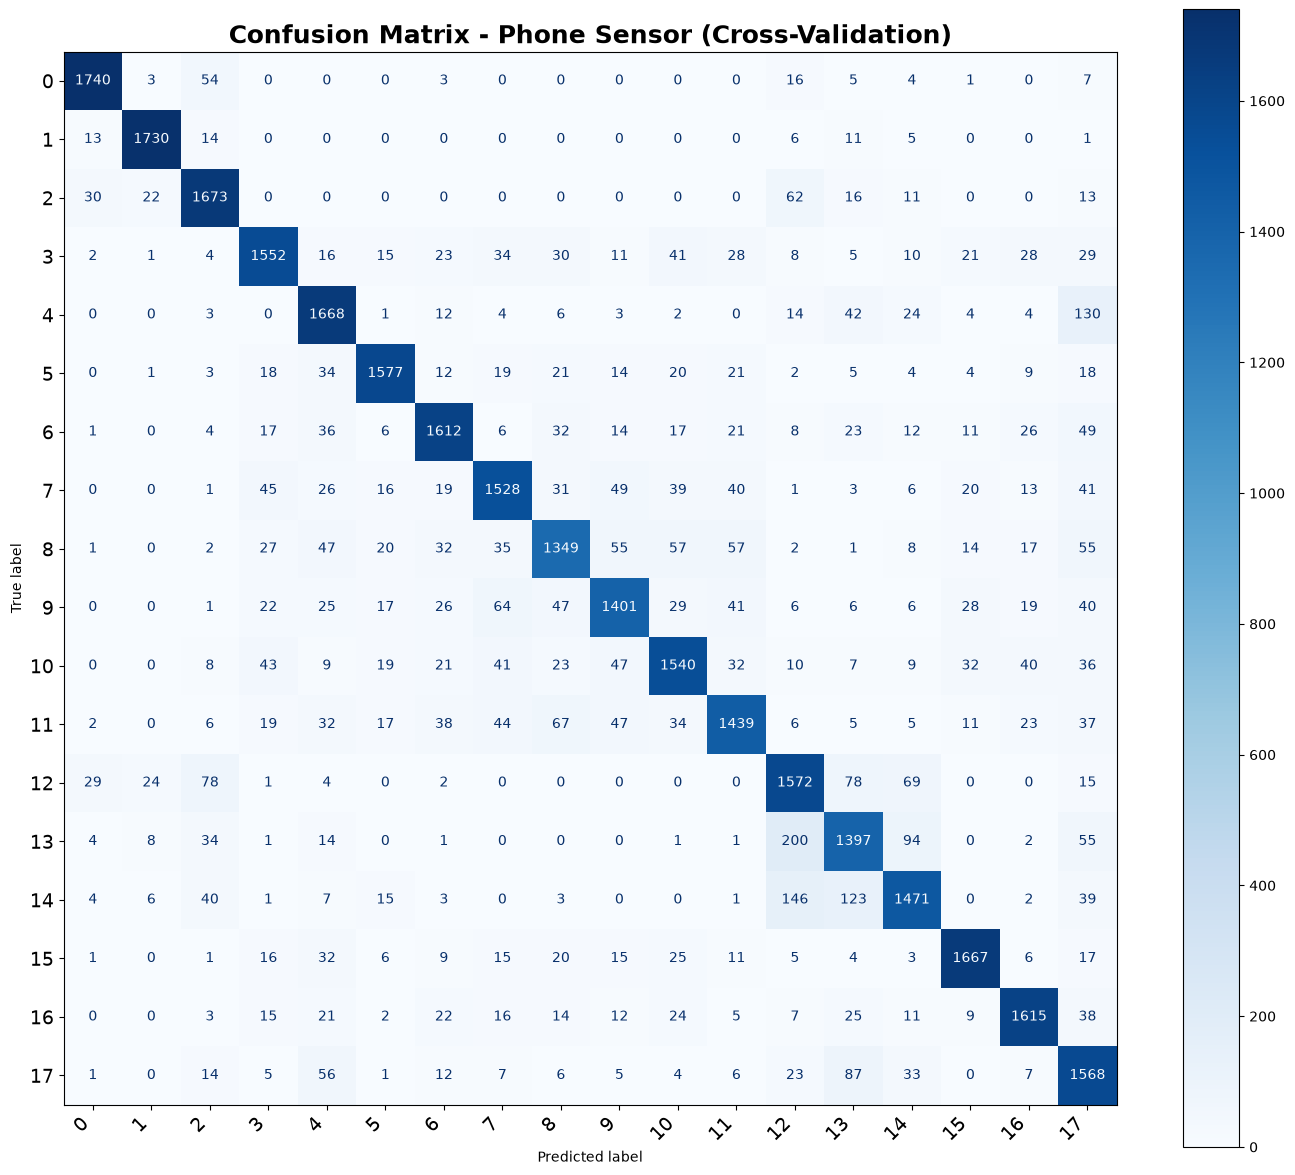

In [13]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

print(classification_report(y_train_phone, y_preds_phone))


cm = confusion_matrix(y_train_phone, y_preds_phone)

fig, ax = plt.subplots(figsize=(14, 12))

# Plot the matrix using the display class
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax, cmap="Blues", values_format="d")

disp.ax_.set_xticklabels(
    disp.ax_.get_xticklabels(),
    rotation=45,
    ha="right",
    fontsize=14,
)

disp.ax_.set_yticklabels(disp.ax_.get_yticklabels(), fontsize=14)

disp.ax_.set_title(
    "Confusion Matrix - Phone Sensor (Cross-Validation)", fontsize=18, fontweight="bold"
)

plt.tight_layout()
plt.show()

In [16]:
y_train_probs = cross_val_predict(
    model,
    X_train_phone,
    y_train_phone,
    cv=3,
    method="predict_proba",
    n_jobs=-1,
)

In [14]:
ACTIVITIES = {
    "A": "Walking",
    "B": "Jogging",
    "C": "Stairs",
    "D": "Sitting",
    "E": "Standing",
    "F": "Typing",
    "G": "Brushing Teeth",
    "H": "Eating Soup",
    "I": "Eating Chips",
    "J": "Eating Pasta",
    "K": "Drinking from Cup",
    "L": "Eating Sandwich",
    "M": "Kicking (Soccer Ball)",
    "O": "Playing Catch w/Tennis Ball",
    "P": "Dribbling (Basketball)",
    "Q": "Writing",
    "R": "Clapping",
    "S": "Folding Clothes",
}

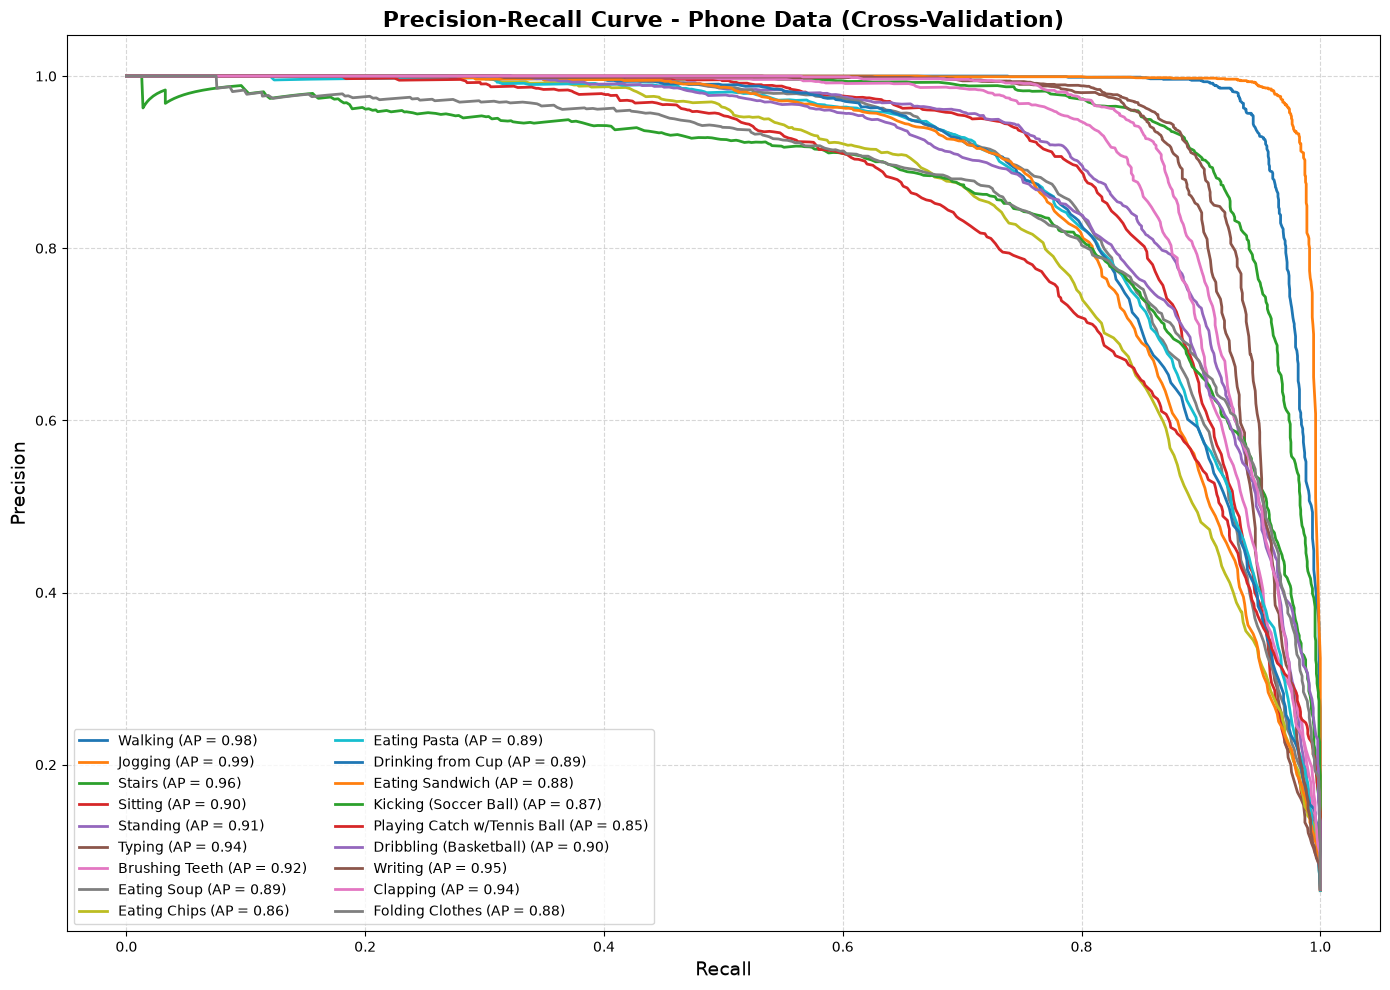

In [18]:
from sklearn.model_selection import cross_val_predict
from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import numpy as np

classes = np.unique(y_train_phone)
y_train_bin = label_binarize(y_train_phone, classes=classes)
n_classes = len(classes)

numeric_to_name = {i: ACTIVITIES[le.inverse_transform([i])[0]] for i in classes}

plt.figure(figsize=(14, 10))

for i in range(n_classes):
    precision, recall, _ = precision_recall_curve(
        y_train_bin[:, i], y_train_probs[:, i]  # type: ignore
    )
    ap_score = average_precision_score(y_train_bin[:, i], y_train_probs[:, i])  # type: ignore

    label_name = numeric_to_name[i]
    plt.plot(recall, precision, lw=2, label=f"{label_name} (AP = {ap_score:.2f})")

plt.xlabel("Recall", fontsize=14)
plt.ylabel("Precision", fontsize=14)
plt.title(
    "Precision-Recall Curve - Phone Data (Cross-Validation)",
    fontsize=16,
    fontweight="bold",
)
plt.legend(
    loc="lower left", fontsize=10, ncol=2
)  # ncol=2 makes it a grid so it doesn't overlap
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

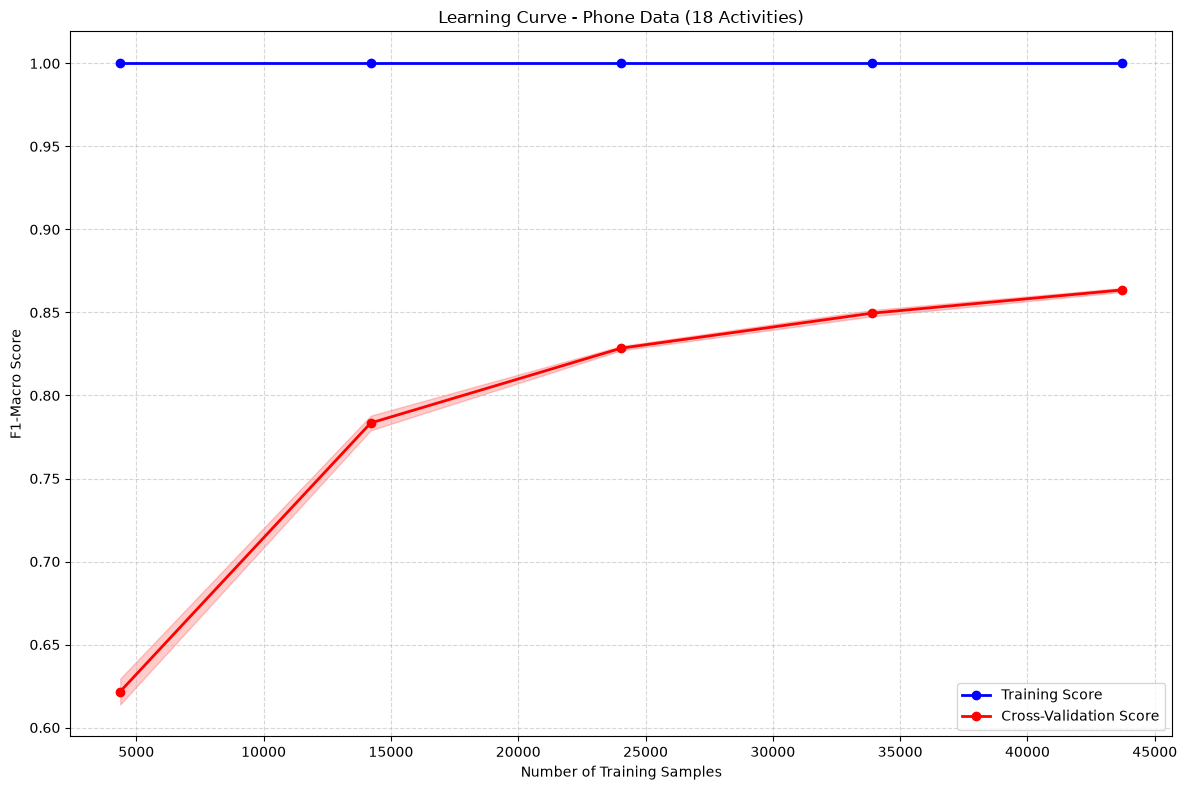

In [62]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

train_sizes, train_scores, val_scores = learning_curve(  # type: ignore
    model,
    X_train_phone,
    y_train_phone,
    cv=3,
    scoring="f1_macro",
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1,
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

plt.figure(figsize=(12, 8))

plt.plot(train_sizes, train_mean, "o-", color="blue", label="Training Score", lw=2)
plt.fill_between(
    train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color="blue"
)

plt.plot(train_sizes, val_mean, "o-", color="red", label="Cross-Validation Score", lw=2)
plt.fill_between(
    train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2, color="red"
)

plt.xlabel(
    "Number of Training Samples",
)
plt.ylabel(
    "F1-Macro Score",
)
plt.title(f"Learning Curve - Phone Data ({len(np.unique(y_train_phone))} Activities)")
plt.legend(
    loc="best",
)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [19]:
model_watch = RandomForestClassifier(
    n_estimators=450,
    max_depth=30,
    min_samples_split=2,
    min_samples_leaf=1,
    criterion="entropy",
    n_jobs=-1,
)

score = cross_val_score(
    model,
    X_train_watch,
    y_train_watch,
    cv=3,
    scoring=make_scorer(f1_score, average="macro"),
    n_jobs=-1,
).mean()

score

np.float64(0.8295928910820853)

In [20]:
from sklearn.model_selection import cross_val_predict

y_preds_watch = cross_val_predict(
    model,
    X_train_watch,
    y_train_watch,
    cv=3,
    n_jobs=-1,
)

              precision    recall  f1-score   support

           0       0.91      0.81      0.86      1838
           1       0.98      0.97      0.97      1821
           2       0.82      0.73      0.77      1747
           3       0.82      0.79      0.80      1832
           4       0.89      0.84      0.86      1875
           5       0.89      0.92      0.91      1815
           6       0.94      0.94      0.94      1875
           7       0.73      0.80      0.76      1869
           8       0.64      0.62      0.63      1794
           9       0.69      0.75      0.72      1829
          10       0.76      0.75      0.76      1871
          11       0.63      0.48      0.54      1827
          12       0.84      0.85      0.85      1889
          13       0.90      0.92      0.91      1789
          14       0.97      0.93      0.95      1889
          15       0.89      0.94      0.92      1837
          16       0.97      0.97      0.97      1859
          17       0.71    

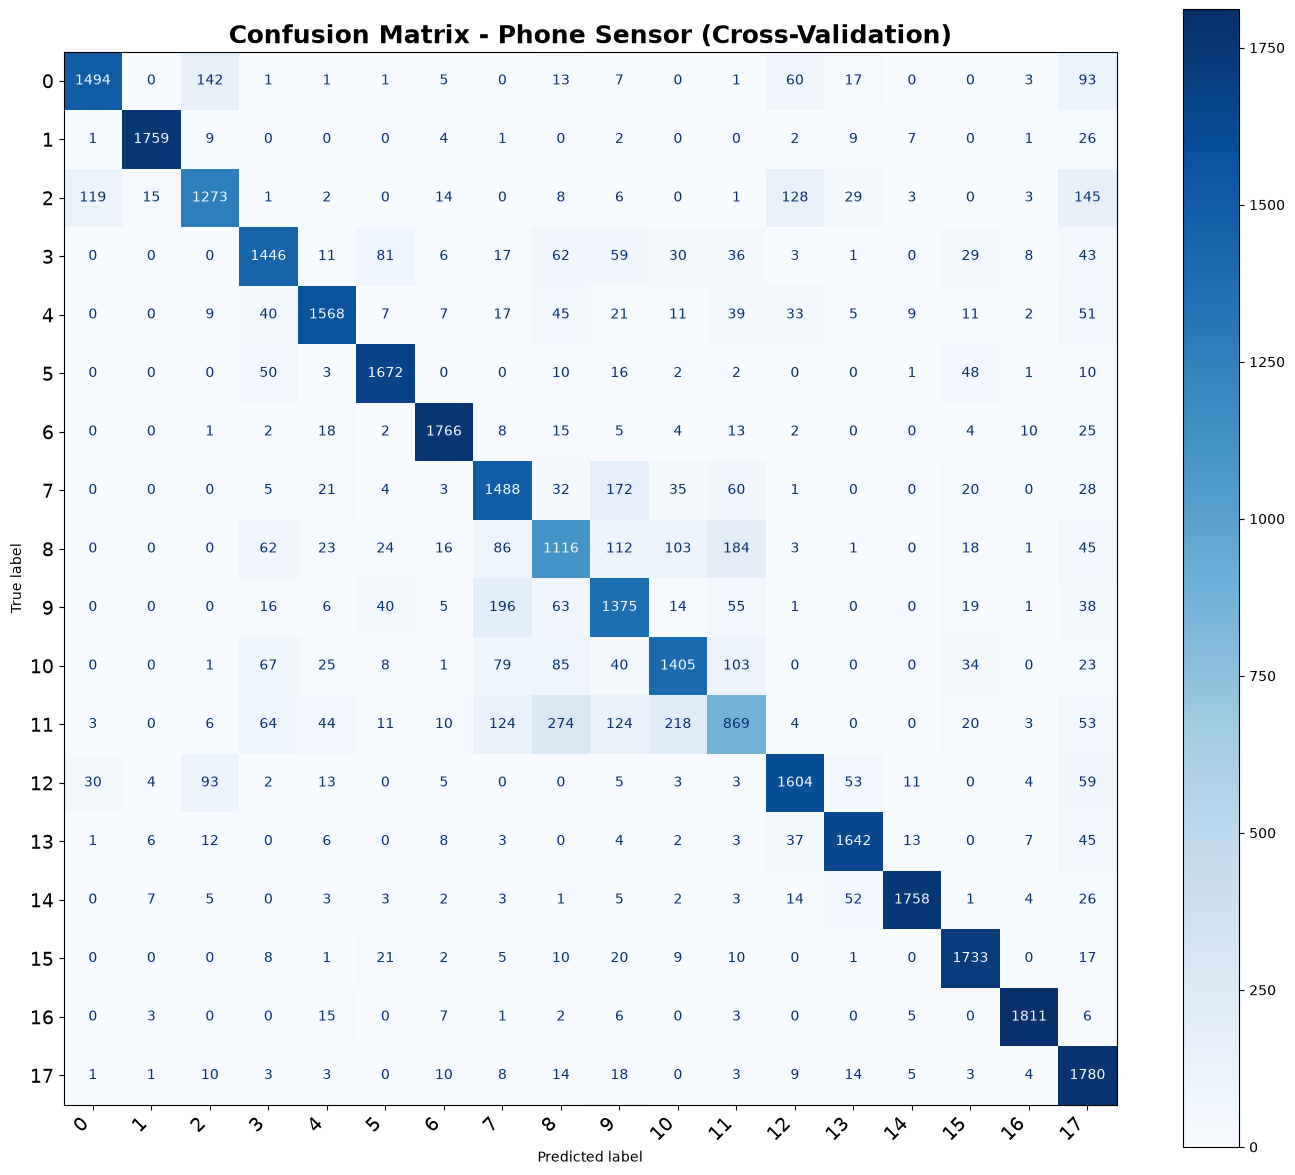

In [21]:
print(classification_report(y_train_watch, y_preds_watch))


cm = confusion_matrix(y_train_watch, y_preds_watch)

fig, ax = plt.subplots(figsize=(14, 12))

# Plot the matrix using the display class
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax, cmap="Blues", values_format="d")

disp.ax_.set_xticklabels(
    disp.ax_.get_xticklabels(),
    rotation=45,
    ha="right",
    fontsize=14,
)

disp.ax_.set_yticklabels(disp.ax_.get_yticklabels(), fontsize=14)

disp.ax_.set_title(
    "Confusion Matrix - Phone Sensor (Cross-Validation)", fontsize=18, fontweight="bold"
)

plt.tight_layout()
plt.show()

In [22]:
y_train_probs = cross_val_predict(
    model,
    X_train_watch,
    y_train_watch,
    cv=3,
    method="predict_proba",
    n_jobs=-1,
)

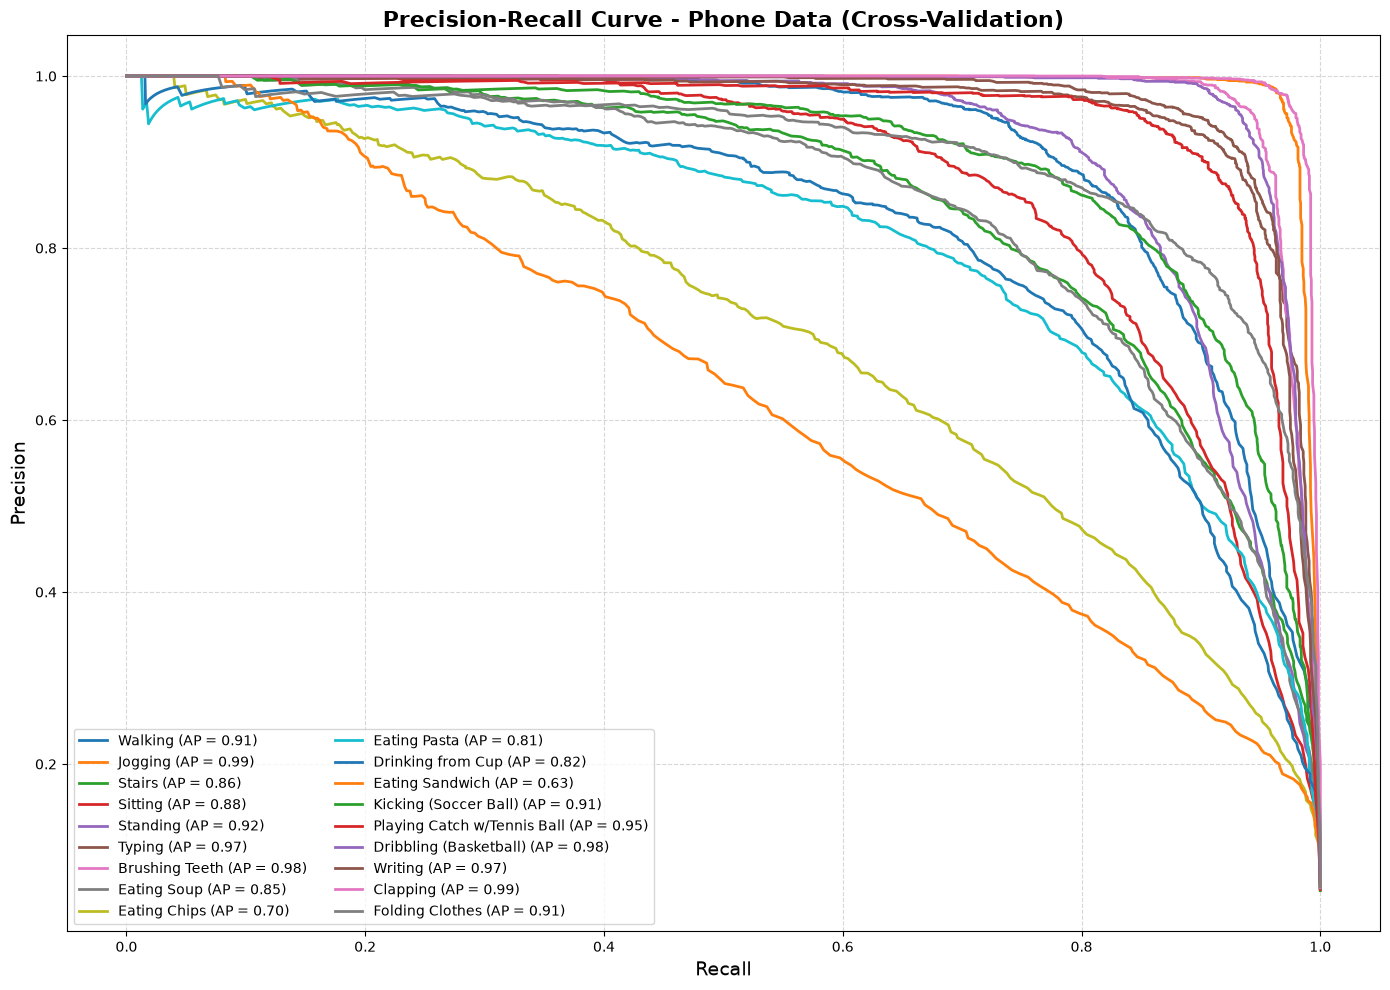

In [24]:
classes = np.unique(y_train_watch)
y_train_bin = label_binarize(y_train_watch, classes=classes)
n_classes = len(classes)

numeric_to_name = {i: ACTIVITIES[le.inverse_transform([i])[0]] for i in classes}

plt.figure(figsize=(14, 10))

for i in range(n_classes):
    precision, recall, _ = precision_recall_curve(
        y_train_bin[:, i], y_train_probs[:, i]  # type: ignore
    )
    ap_score = average_precision_score(y_train_bin[:, i], y_train_probs[:, i])  # type: ignore

    label_name = numeric_to_name[i]
    plt.plot(recall, precision, lw=2, label=f"{label_name} (AP = {ap_score:.2f})")

plt.xlabel("Recall", fontsize=14)
plt.ylabel("Precision", fontsize=14)
plt.title(
    "Precision-Recall Curve - Phone Data (Cross-Validation)",
    fontsize=16,
    fontweight="bold",
)
plt.legend(
    loc="lower left", fontsize=10, ncol=2
)  # ncol=2 makes it a grid so it doesn't overlap
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, f1_score

def objective(trial):

    n_estimators = trial.suggest_int("n_estimators", 100, 500)

    max_depth = trial.suggest_int("max_depth", 5, 50)

    min_samples_split = trial.suggest_int("min_samples_split", 2, 5)

    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 5)

    criterion = trial.suggest_categorical("criterion", ["entropy", "gini"])

    max_features = trial.suggest_categorical(
        "max_features", ["sqrt", "log2", 0.3, 0.5, 0.7]
    )

    max_samples = trial.suggest_categorical("max_samples", [0.9, 1])

    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        criterion=criterion,
        max_features=max_features,
        max_samples=max_samples,
        bootstrap=True,
        n_jobs=-1,
        random_state=42,
    )

    score = cross_val_score(
        model,
        X_train_watch,
        y_train_watch,
        cv=3,
        scoring=make_scorer(f1_score, average="macro"),
        n_jobs=-1,
    ).mean()

    return score


study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(),
)


study.optimize(objective, n_trials=50)